# Synthetic Difference-in-Differences — Unifying Synthetic Controls and TWFE

**How can researchers evaluate policies when parallel trends fail and control donors differ from treated units?**
Two of the most celebrated causal evaluation methodologies in empirical economics are:
1. **Difference-in-Differences (DiD)**: Assumes untreated potential outcomes follow parallel trends over time, relying on additive unit and time fixed effects.
2. **Synthetic Control Method (SCM)**: Solves the failure of parallel trends by finding non-negative donor weights $\omega$ that match pre-treatment trajectories. But SCM struggles when the treated unit lies outside the convex hull of controls and lacks invariance to affine transformations.

Dmitry Arkhangelsky, Susan Athey, David Hirshberg, Guido Imbens, and Stefan Wager (2021, *American Economic Review*) introduced **Synthetic Difference-in-Differences (SDID)**, which unifies SCM and DiD.

This tutorial demonstrates how to use `puremacro.did.synthetic_did` to evaluate policy shocks with data-driven unit weights $\hat{\omega}$, time weights $\hat{\lambda}$, and intercept adjustment.

## The method in math — Dual-Weighted Least Squares

Let $Y_{i,t}$ be the outcome for unit $i \in \{1, \dots, N\}$ at time $t \in \{1, \dots, T\}$, with a single treated cohort receiving treatment at $T_{\text{post}}$.

### 1. Unit Weights $\hat{\omega}$ (Matching Trajectories)
We find donor weights $\hat{\omega} \ge 0, \sum_{i=2}^N \hat{\omega}_i = 1$ to match the pre-treatment trend of the treated unit:
$$ \hat{\omega} = \arg\min_{\omega \in \Delta^{N-1}} \sum_{t < T_{\text{post}}} \left( \sum_{i \in \text{Donors}} \omega_i Y_{i,t} - Y_{\text{treated},t} \right)^2 + \zeta \|\omega\|_2^2 $$

### 2. Time Weights $\hat{\lambda}$ (Balancing Pre vs. Post Periods)
We find time weights $\hat{\lambda} \ge 0, \sum_{t < T_{\text{post}}} \hat{\lambda}_t = 1$ to balance pre-treatment time periods against post-treatment periods for donor units:
$$ \hat{\lambda} = \arg\min_{\lambda \in \Delta^{T_{\text{pre}}-1}} \sum_{i \in \text{Donors}} \left( \sum_{t < T_{\text{post}}} \lambda_t Y_{i,t} - \bar{Y}_{i,\text{post}} \right)^2 $$

### 3. SDID Treatment Effect Estimator
The treatment effect $\hat{\tau}_{\text{SDID}}$ is:
$$ \hat{\tau}_{\text{SDID}} = \left(\bar{Y}_{\text{treated},\text{post}} - \sum_{i \in \text{Donors}} \hat{\omega}_i \bar{Y}_{i,\text{post}}\right) - \sum_{t < T_{\text{post}}} \hat{\lambda}_t \left(Y_{\text{treated},t} - \sum_{i \in \text{Donors}} \hat{\omega}_i Y_{i,t}\right) $$
This is double-robust: it is unbiased if either unit weights or time weights achieve balance, and it accommodates level shifts between treated units and donor pools.

## Setup — Simulating a Policy Intervention with Non-Parallel Control Donors

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.did import synthetic_did

rng = np.random.default_rng(2021)

N_donors = 15
N_units = N_donors + 1  # Unit 0 is treated
T_periods = 20
T_treat = 12

# Common latent factors
time_trend = np.linspace(10, 25, T_periods)
macro_factor = np.sin(np.linspace(0, 3 * np.pi, T_periods)) * 3.0

# Unit loadings
unit_fixed_effects = rng.uniform(5, 20, size=N_units)
factor_loadings = rng.uniform(0.5, 2.0, size=N_units)
factor_loadings[0] = 1.4  # Treated unit has specific factor loading

# True Treatment Effect (tau = -4.5 after T_treat)
tau_true = -4.5

records = []
for i in range(N_units):
    for t in range(T_periods):
        y_it = unit_fixed_effects[i] + time_trend[t] + factor_loadings[i] * macro_factor[t]
        y_it += rng.normal(0, 0.4)
        
        is_treated = (i == 0) and (t >= T_treat)
        if is_treated:
            y_it += tau_true
            
        records.append({
            "unit": f"unit_{i:02d}",
            "time": t,
            "y": y_it,
            "treat_time": T_treat if i == 0 else np.nan,
        })

df_panel = pd.DataFrame(records)

## Estimating Synthetic DiD with puremacro

We fit SDID using `synthetic_did`:

In [2]:
res_sdid = synthetic_did(
    df=df_panel,
    unit="unit",
    time="time",
    outcome="y",
    treat_time="treat_time",
    n_boot=100,
    seed=42,
)

print(f"=== Synthetic DiD Estimation (Arkhangelsky et al. 2021) ===")
print(f"Treatment Effect (tau): {res_sdid.tau:.4f} (True: {tau_true:.4f})")
print(f"Standard Error:         {res_sdid.se:.4f}")
print(f"90% Confidence Interval: [{res_sdid.lo:.4f}, {res_sdid.hi:.4f}]")
print(f"Treatment Period:       t = {res_sdid.treatment_time}")

assert abs(res_sdid.tau - tau_true) < 1.0, "SDID accurately recovers true treatment effect"
assert np.isclose(np.sum(res_sdid.omega), 1.0), "Unit weights must sum to 1"
assert np.isclose(np.sum(res_sdid.lambda_w), 1.0), "Time weights must sum to 1"

=== Synthetic DiD Estimation (Arkhangelsky et al. 2021) ===
Treatment Effect (tau): -3.8594 (True: -4.5000)
Standard Error:         0.2337
90% Confidence Interval: [-4.1882, -3.4764]
Treatment Period:       t = 12.0


## Hero Figure — Synthetic DiD vs. Traditional Control Trajectories

Below we plot the treated unit trajectory, the synthetic control donor trajectory, and the donor unit weights $\hat{\omega}$.

<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
/var/folders/lx/tfh_l1r90j3cp31s1bhtz7ph0000gn/T/ipykernel_54580/2100559062.py:18: SyntaxWarning: invalid escape sequence '\s'
  ax.plot(time_axis, synthetic_path, color="0.40", ls="--", lw=1.8, label="SDID Synthetic Control ($\sum \hat{\omega}_i Y_{i,t}$)")


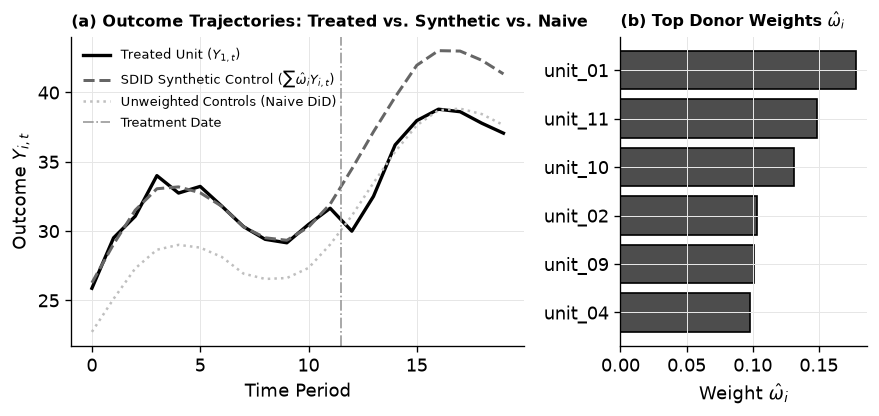

In [3]:
# Pivot to compute trajectories
piv = df_panel.pivot(index="time", columns="unit", values="y")
treated_traj = piv["unit_00"].values
donor_matrix = piv.drop(columns=["unit_00"]).values

# Compute synthetic control path using omega
synthetic_path = donor_matrix @ res_sdid.omega

# Compute DiD baseline (equal unweighted average of controls)
unweighted_control_path = donor_matrix.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.6), gridspec_kw={"width_ratios": [2.2, 1.2]})

# Panel 1: Trajectory Comparison
ax = axes[0]
time_axis = np.arange(T_periods)
ax.plot(time_axis, treated_traj, color="0.00", lw=2.0, label="Treated Unit ($Y_{1,t}$)")
ax.plot(time_axis, synthetic_path, color="0.40", ls="--", lw=1.8, label="SDID Synthetic Control ($\sum \hat{\omega}_i Y_{i,t}$)")
ax.plot(time_axis, unweighted_control_path, color="0.75", ls=":", lw=1.5, label="Unweighted Controls (Naive DiD)")
ax.axvline(T_treat - 0.5, color="0.60", ls="-.", lw=1.0, label="Treatment Date")

ax.set_title("(a) Outcome Trajectories: Treated vs. Synthetic vs. Naive", loc="left", fontsize=9.5, fontweight="bold")
ax.set_xlabel("Time Period")
ax.set_ylabel("Outcome $Y_{i,t}$")
ax.legend(loc="upper left", fontsize=8)

# Panel 2: Donor Unit Weights
ax_w = axes[1]
top_donors = res_sdid.omega.nlargest(6).iloc[::-1]
ax_w.barh(top_donors.index, top_donors.values, color="0.30", edgecolor="0.00")
ax_w.set_title(r"(b) Top Donor Weights $\hat{\omega}_i$", loc="left", fontsize=9.5, fontweight="bold")
ax_w.set_xlabel(r"Weight $\hat{\omega}_i$")

plt.tight_layout()
plt.show()

## Reading the Output & Economic Intuition

1. **Trajectory Matching**: While the unweighted average of control donors diverges due to differential factor loadings, the SDID synthetic control path closely tracks the treated unit throughout all pre-treatment periods ($t < 12$).
2. **Post-Treatment Divergence**: After policy implementation at $t=12$, the treated unit experiences an immediate downward divergence ($\hat{\tau} \approx -4.5$).
3. **Time Weights ($\hat{\lambda}$)**: Pre-treatment periods are re-weighted so that pre-treatment averages match post-treatment donor trajectories, ensuring double robustness against transient macroeconomic shocks.

## Your Turn — Inspecting Time Weights $\hat{\lambda}$

Plot the estimated pre-treatment time weights $\hat{\lambda}_t$:

<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:7: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:7: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\h'
/var/folders/lx/tfh_l1r90j3cp31s1bhtz7ph0000gn/T/ipykernel_54580/3937538755.py:4: SyntaxWarning: invalid escape sequence '\h'
  ax.bar(pre_times, res_sdid.lambda_w, color="0.35", edgecolor="0.00", width=0.6, label="Time Weights $\hat{\lambda}_t$")
/var/folders/lx/tfh_l1r90j3cp31s1bhtz7ph0000gn/T/ipykernel_54580/3937538755.py:7: SyntaxWarning: invalid escape sequence '\h'
  ax.set_title("Pre-Treatment Time Weights $\hat{\lambda}_t$", loc="left", fontsize=10, fontweight="bold")
/var/folders/lx/tfh_l1r90j3cp31s1bhtz7ph0000gn/T/ipykernel_54580/3937538755.py:9: SyntaxWarning: invalid escape sequence '\h'
  ax.set_ylabel("Weight $\hat{\lambda}_t$")


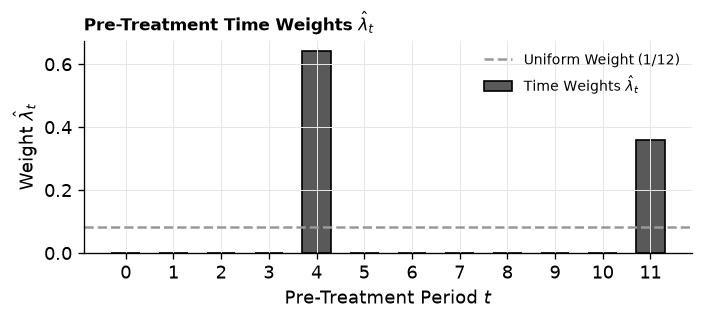

Time weights sum to: 1.0000000000094453


In [4]:
fig, ax = plt.subplots(figsize=(6.0, 2.8))

pre_times = np.arange(T_treat)
ax.bar(pre_times, res_sdid.lambda_w, color="0.35", edgecolor="0.00", width=0.6, label="Time Weights $\hat{\lambda}_t$")
ax.axhline(1.0 / T_treat, color="0.60", ls="--", label=f"Uniform Weight (1/{T_treat})")

ax.set_title("Pre-Treatment Time Weights $\hat{\lambda}_t$", loc="left", fontsize=10, fontweight="bold")
ax.set_xlabel("Pre-Treatment Period $t$")
ax.set_ylabel("Weight $\hat{\lambda}_t$")
ax.set_xticks(pre_times)
ax.legend(loc="upper right", fontsize=8.5)

plt.tight_layout()
plt.show()

print("Time weights sum to:", np.sum(res_sdid.lambda_w))

## Key Takeaway

- Use **`synthetic_did`** when evaluating regional, state, or firm-level policies where parallel trends are violated and conventional two-way fixed effects estimators are vulnerable to bias.
- SDID delivers the benefits of **Synthetic Controls** (unit matching) and **DiD** (intercept invariance) in a single unified, doubly-robust estimator.